In [1]:
data = {}
data['isic2018'] = {    #f1-mean f1-max miou-mean miou-max
    'UMergeNet':        [0.907, 0.910, 0.837, 0.842],
    'U-Net':            [0.896, 0.897, 0.820, 0.824],
    'Attention U-Net':  [0.895, 0.897, 0.819, 0.821],
    'R2Atten U-Net':    [0.900, 0.903, 0.825, 0.831],
    'UNeXt':            [0.904, 0.906, 0.832, 0.836],
    'U-Lite':           [0.907, 0.912, 0.837, 0.846],
    'DeepLabV3':        [0.911, 0.912, 0.842, 0.844],
    'YOLOv11':          [0.667, 0.667, 0.581, 0.581],
}

data['fuseg'] = {
    'UMergeNet':        [ 0.953, 0.954, 0.914, 0.916],
    'U-Net':            [ 0.956, 0.958, 0.919, 0.923],
    'Attention U-Net':  [ 0.954, 0.956, 0.917, 0.919],
    'R2Atten U-Net':    [ 0.935, 0.937, 0.886, 0.888],
    'UNeXt':            [ 0.943, 0.944, 0.897, 0.901],
    'U-Lite':           [ 0.944, 0.947, 0.900, 0.904],
    'DeepLabV3':        [ 0.891, 0.893, 0.823, 0.826],
    'YOLOv11':          [ 0.843, 0.843, 0.787, 0.787],
}
data['lars'] = {
    'UMergeNet':        [ 0.983, 0.984, 0.967, 0.968],
    'U-Net':            [ 0.984, 0.984, 0.969, 0.970],
    'Attention U-Net':  [ 0.984, 0.985, 0.969, 0.971],
    'R2Atten U-Net':    [ 0.980, 0.980, 0.961, 0.962],
    'UNeXt':            [ 0.980, 0.981, 0.961, 0.963],
    'U-Lite':           [ 0.978, 0.979, 0.958, 0.959],
    'DeepLabV3':        [ 0.968, 0.969, 0.940, 0.941],
    'YOLOv11':          [ 0.459, 0.415, 0.512, 0.508],
}
data['glas'] = {
    'UMergeNet':        [ 0.933, 0.937, 0.875, 0.881],
    'U-Net':            [ 0.927, 0.930, 0.865, 0.870],
    'Attention U-Net':  [ 0.932, 0.934, 0.873, 0.876],
    'R2Atten U-Net':    [ 0.886, 0.906, 0.796, 0.828],
    'UNeXt':            [ 0.929, 0.933, 0.868, 0.874],
    'U-Lite':           [ 0.921, 0.928, 0.854, 0.866],
    'DeepLabV3':        [ 0.860, 0.867, 0.755, 0.765],
    'YOLOv11':          [ 0.897, 0.897, 0.822, 0.822],
}


FPS = {               #GPU  CPU  
    'UMergeNet':      [1233, 34.17],
    'U-Net':          [184, 3.46],
    'Attention U-Net':[168, 3.02],
    'R2Atten U-Net':  [67.80, 1.30],
    'UNeXt':          [3529, 121],
    'U-Lite':         [1256, 27.96],
    'DeepLabV3':      [3184, 68.17],
    'YOLOv11':        [781, 602]
}


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


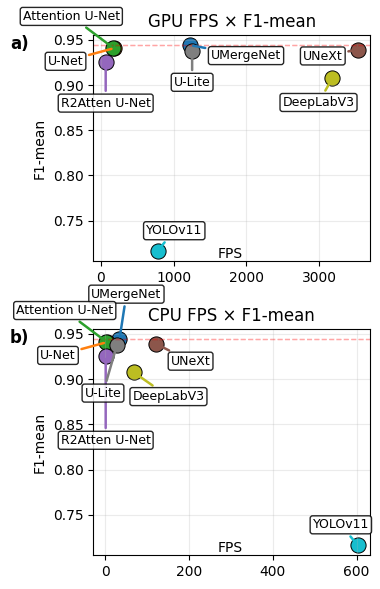

In [2]:
import matplotlib.pyplot as plt
import numpy as np

models = list(FPS.keys())

# Average F1-mean across datasets
f1_means = {}
for model in models:
    vals = [d[model][0] for d in data.values()]  # index 0 = F1-mean
    f1_means[model] = np.mean(vals)

fps_gpu = {m: FPS[m][0] for m in models}
fps_cpu = {m: FPS[m][1] for m in models}

# -----------Set the positions manually HERE -----------
# format: ('left'/'right', 'up'/'down', dx, dy)
# If the model is not here, use default_pos
label_pos_gpu = {
    'UMergeNet':     ('right', 'down',  40, 10),
    'U-Lite':        ('right', 'down',  0, 25),
    'UNeXt':         ('left',  'down',  25, 7),
    'Attention U-Net': ('left',  'up',  30, 20),
    'U-Net':         ('left',  'down',  35, 12),
    'DeepLabV3':     ('left',  'down',  10, 20),
    'YOLOv11':       ('right', 'up',    12, 12),
    'R2Atten U-Net': ('left',  'down',  0, 32),
}

label_pos_cpu = {
    'UMergeNet':     ('right',  'up',   5, 30),
    'U-Lite':        ('left', 'down',   10, 37),
    'UNeXt':         ('right', 'down',  25, 15),
    'Attention U-Net': ('left',  'up',  30, 20),
    'U-Net':         ('left',  'down',  35, 12),
    'DeepLabV3':     ('right',  'down', 25, 20),
    'YOLOv11':       ('left', 'up',     12, 12),
    'R2Atten U-Net': ('left',  'down',  0, 63),
}

default_pos = ('right', 'up', 8, 8)


best_model = max(f1_means, key=f1_means.get)
best_f1 = f1_means[best_model]

# ---------- converter helper (hor,ver,dx,dy) ----------
def compute_offset(hor, ver, dx, dy):
    dx = dx if hor == 'right' else -dx
    dy = dy if ver == 'up' else -dy
    return dx, dy

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
color_map = {model: colors[i] for i, model in enumerate(models)}

# ----------function to plot with texts ----------
def scatter_with_custom_labels(ax, fps_dict, title, label_map):
    for model in models:
        x = fps_dict[model]
        y = f1_means[model]
        cmap_color = color_map[model]

        # Point
        ax.scatter(x, y, color=cmap_color, s=120, edgecolor='black', linewidth=0.7)
        ax.axhline(best_f1, color='red', linestyle='--', linewidth=1, alpha=0.05)

        # catch pos (or default)
        hor, ver, dx, dy = label_map.get(model, default_pos)
        dx, dy = compute_offset(hor, ver, dx, dy)

        # annotation with line
        ax.annotate(
            model,
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85),
            arrowprops=dict(arrowstyle="-", lw=1.8, color=cmap_color),
            horizontalalignment='center'
        )

    ax.set_title(title)
    #Ax.set xlabel("fps")
    ax.set_ylabel("F1-mean")
    ax.grid(True, alpha=0.25)

# ----------Full ----------
fig, axes = plt.subplots(2, 1, figsize=(4, 6))
ax_gpu, ax_cpu = axes

scatter_with_custom_labels(ax_gpu, fps_gpu, "GPU FPS × F1-mean", label_pos_gpu)
scatter_with_custom_labels(ax_cpu, fps_cpu, "CPU FPS × F1-mean", label_pos_cpu)

# caption with colors
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color_map[m], label=m,
               markersize=9, markeredgecolor='black')
    for m in models
]

#fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4)
ax_gpu.text(-0.3, 1.0, "a)", transform=ax_gpu.transAxes,
            fontsize=12, fontweight='bold', va='top')

ax_cpu.text(-0.3, 1.0, "b)", transform=ax_cpu.transAxes,
            fontsize=12, fontweight='bold', va='top')


ax_gpu.text(0.45, 0.0, "FPS", transform=ax_gpu.transAxes,
            fontsize=10, va='bottom')

ax_cpu.text(0.45, 0.0, "FPS", transform=ax_cpu.transAxes,
            fontsize=10, va='bottom')

plt.tight_layout()
fig.subplots_adjust(hspace=0.30)
plt.savefig("f1mean_vs_fps.eps", format="eps", dpi=300)
plt.show()

